# Figure 7 - Whole-brain gradients and eigenmodes analysis

In [71]:
import sys
sys.path.append("..")

from main import *
from zebrafish import *

from scipy.stats import zscore, spearmanr
from scipy.stats import percentileofscore
from brainsmash.mapgen.base import Base

# Part 1: Measuring functional gradients and correlating with eigenmodes

# Loading whole-brain data

In [72]:
# Loading whole-brain functional data
nodes = np.load('../Files/PaperNetworks/centroids_hires.npy')
FC = np.load('../Files/PaperNetworks/FC_hires_spontaneous.npy')
FC_stim = np.load('../Files/PaperNetworks/FC_hires_stim.npy')

# Loading whole-brain eigenmodes
eigenmodes = np.load('../Files/zebrafish_wholebrain_eigenmodes_single.npy')
vertices = np.load('../Files/zebrafish_wholebrain_vertices_single.npy')

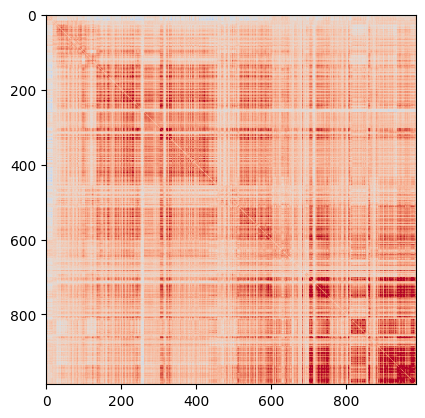

In [73]:
plt.imshow(FC, cmap='coolwarm', vmin=-0.5, vmax=0.5)

# Correlation vs distance relationship

In [74]:
d = compute_distances(nodes, nodes)
R = FC.shape[0]
d = (1 / 3) * (d[:R, :R] + d[R:, R:] + d[:R, R:])

In [75]:
%matplotlib inline

In [76]:
triangle = np.triu_indices(FC.shape[0], 1)

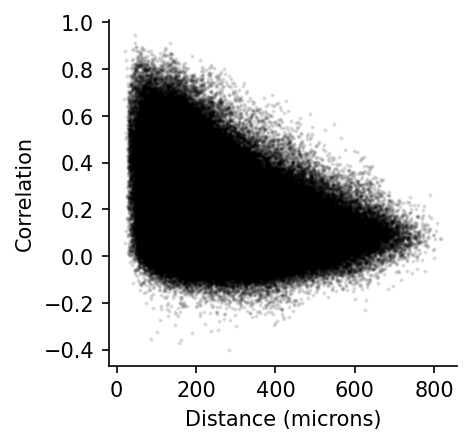

In [77]:
fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
ax.scatter(d[triangle], FC[triangle], alpha=0.1, color='black', edgecolor=None, s=1, rasterized=True)
ax.set_xlabel('Distance (microns)')
ax.set_ylabel('Correlation')
ax.spines[['top', 'right']].set_visible(False)


In [78]:
spearmanr(d[triangle], FC[triangle])

SpearmanrResult(correlation=-0.297804116828618, pvalue=0.0)

In [79]:
d_values = d[triangle]
FC_values = FC[triangle]

# Gradients & eigenmodes

In [80]:
N_modes = FC.shape[0]
gradients, _ = diffusion_mapping(np.abs(FC), n_components=N_modes)

/home/anleg84/anaconda3/envs/calimba/lib/python3.9/site-packages/scipy/sparse/linalg/_eigen/arpack/arpack.py:1592: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  warnings.warn("k >= N for N * N square matrix. "


In [81]:
d = compute_distances(vertices, nodes[:FC.shape[0]])
eigenmodes_ = eigenmodes[:, np.argmin(d, axis=0)]

In [82]:
mode_similarity, mapping = compute_mode_similarity_matrix(eigenmodes_[1:31], gradients.T[:30], return_mapping=True)

Text(0.5, 0, 'Functional gradients')

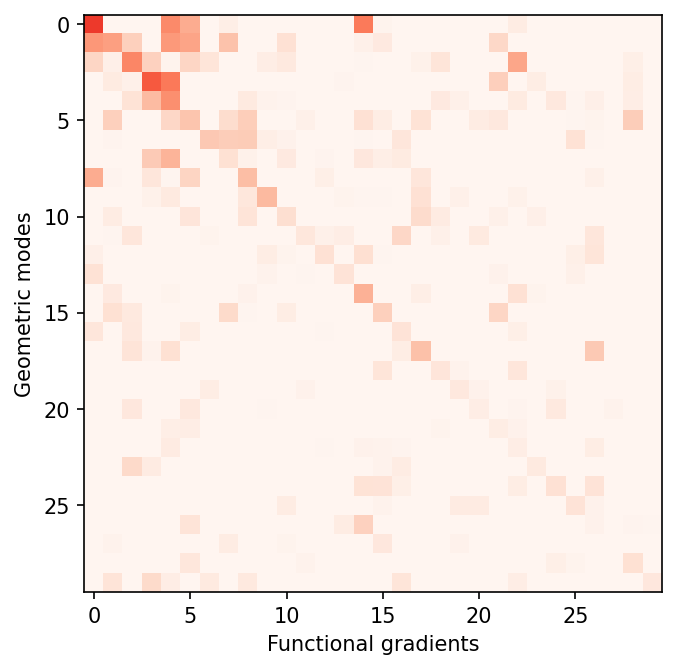

In [83]:
plt.figure(figsize=(5, 5), dpi=150)

plt.imshow(np.abs(mode_similarity), cmap='Reds', vmin=0.1, vmax=0.75)
plt.ylabel('Geometric modes')
plt.xlabel('Functional gradients')

# Spatial statistics

In [14]:
def shuffle_vector_brainsmash(vector, distances, resample=True, n_iters=1):
    base = Base(x=vector, D=distances, resample=resample)
    surrogate = base(n=n_iters)
    return surrogate

def shuffle_vectors_brainsmash(vectors, distances, resample=True):
    shuffled_vectors = []
    for v in vectors:
        base = Base(x=v, D=distances, resample=resample)
        surrogate = base(n=1)
        shuffled_vectors.append(surrogate)
    return np.array(shuffled_vectors)

In [15]:
empirical_score = np.mean(np.abs(np.diag(mode_similarity))[:30])
print(empirical_score)

0.21622823735490773


In [16]:
modes1, modes2 = eigenmodes_[1:31], gradients.T[:30]
d = compute_distances(nodes[:FC.shape[0]], nodes[:FC.shape[0]])

In [ ]:
null_similarity_matrices = []

for _ in tqdm(range(1000)):
    
    shuffled_modes1 = shuffle_vectors_brainsmash(modes1, d, resample=False)
    corrs_null = compute_mode_similarity_matrix(shuffled_modes1, modes2, return_mapping=False)
    null_similarity_matrices.append(corrs_null)

null_similarity_matrices = np.stack(null_similarity_matrices, axis=0)

In [ ]:
np.save('../Results/null_similarity_wholebrain.npy', null_similarity_matrices)

#### Loading and computing stats

In [ ]:
null_similarity_matrices = np.load('../Results/null_similarity_wholebrain.npy')

In [ ]:
plt.figure(figsize=(5, 5), dpi=150)

plt.imshow(np.abs(null_similarity_matrices[5]), cmap='Reds', vmin=0.1, vmax=0.75)
plt.ylabel('Geometric modes')
plt.xlabel('Functional gradients')

In [ ]:
null_scores = []
for m in null_similarity_matrices:
    null_scores.append(np.mean(np.abs(np.diag(m))[:30]))

In [ ]:
percentileofscore(null_scores, empirical_score)

# Plotting eigenmodes and gradients

In [27]:
def figure_to_array(fig):
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    array = np.fromstring(fig.canvas.tostring_argb(), dtype=np.uint8)
    array.shape = (h, w, 4)
    array = np.roll(array, 3, axis=2)
    return array

Pre-rendering the 3D scatter plots of whole-brain eigenmodes and gradients in RGB arrays to facilitate the multipanel figure later.

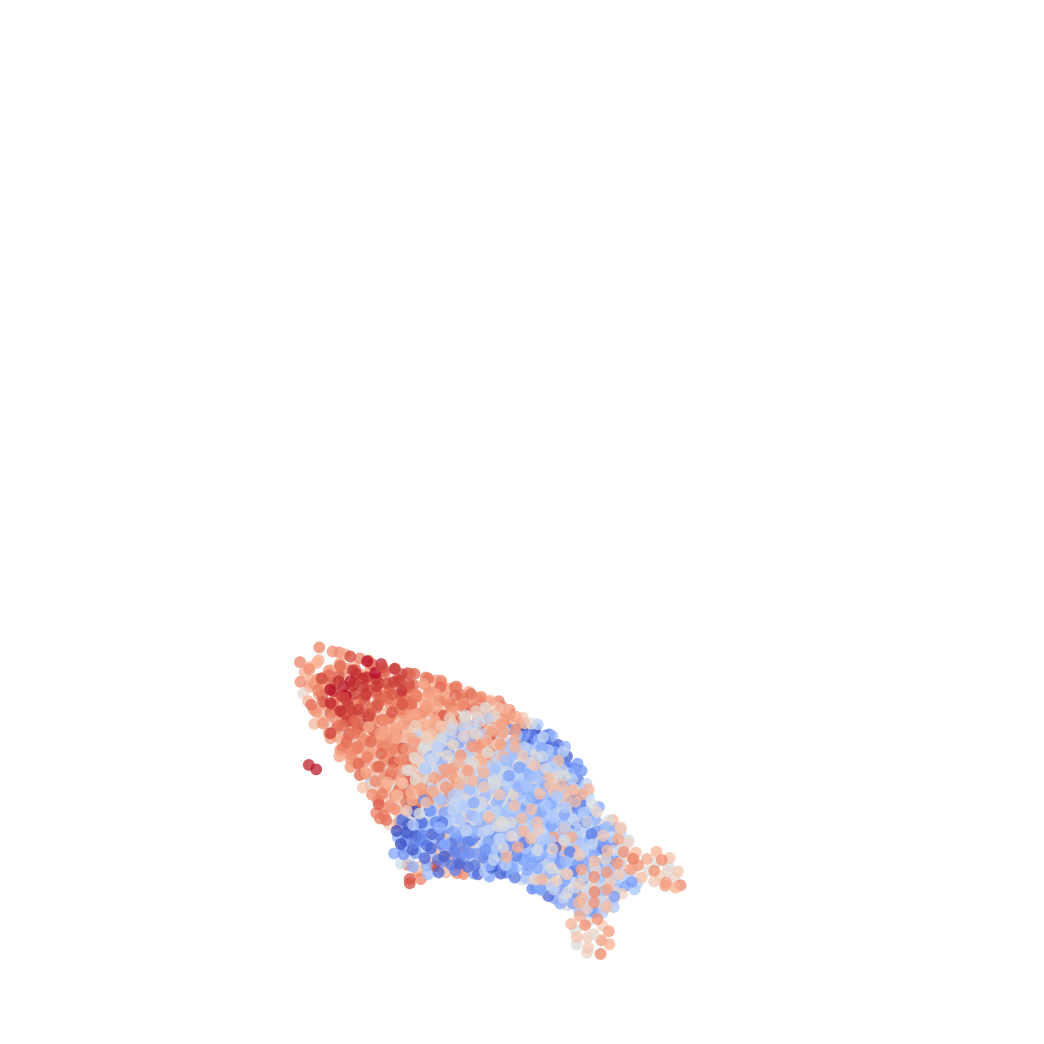

In [28]:
i = 0
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(2, 2), dpi=600)
ax.scatter(nodes[:, 0], nodes[:, 1], -nodes[:, 2], c=np.sign(mode_similarity[i, i]) * double(gradients[:, mapping[i]]), alpha=0.75, cmap='coolwarm', s=2, edgecolor='None')
ax.set_axis_off()
#ax.set_ylim(ax.get_ylim()[::-1])
#ax.set_zlim(ax.get_zlim()[::-1])
ax.set_xlim([0, 1000])
ax.set_ylim([0, 1000])
ax.set_zlim([0, 1000])
ax.view_init(elev=40, azim=-140)
plt.show()

In [29]:
figures_gradients = []

for i in range(30):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(2, 2), dpi=600)
    ax.scatter(nodes[:, 0], nodes[:, 1], -nodes[:, 2], c=np.sign(mode_similarity[i, i]) * double(gradients[:, mapping[i]]), alpha=0.75, cmap='coolwarm', s=2, edgecolor='None')
    ax.set_axis_off()
    #ax.set_ylim(ax.get_ylim()[::-1])
    #ax.set_zlim(ax.get_zlim()[::-1])
    ax.set_xlim([0, 1000])
    ax.set_ylim([0, 1000])
    ax.set_zlim([0, 1000])
    ax.view_init(elev=40, azim=-140)
    #plt.show()
    
    fig_array = figure_to_array(fig)
    figures_gradients.append(fig_array[720:1050, 375:790])
    plt.close()

/tmp/ipykernel_19526/301260471.py:4: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  array = np.fromstring(fig.canvas.tostring_argb(), dtype=np.uint8)


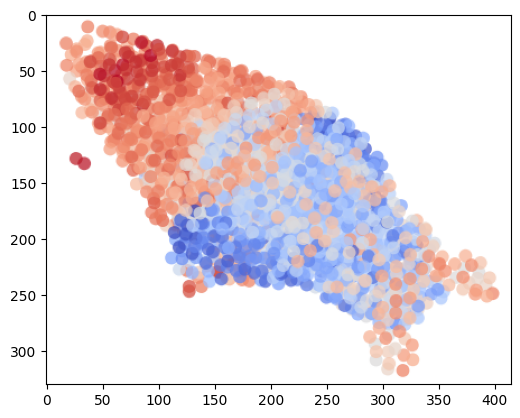

In [30]:
plt.imshow(figures_gradients[0])

In [31]:
figures_eigenmodes = []

for i in range(10):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(2, 2), dpi=600)
    ax.scatter(nodes[:, 0], nodes[:, 1], -nodes[:, 2], c=double(eigenmodes_[i+1]), alpha=0.75, cmap='coolwarm', s=2, edgecolor='None')
    ax.set_axis_off()
    #ax.set_ylim(ax.get_ylim()[::-1])
    #ax.set_zlim(ax.get_zlim()[::-1])
    ax.set_xlim([0, 1000])
    ax.set_ylim([0, 1000])
    ax.set_zlim([0, 1000])
    ax.view_init(elev=40, azim=-140)
    #plt.show()

    
    fig_array = figure_to_array(fig)
    figures_eigenmodes.append(fig_array[720:1050, 375:790])
    plt.close()

/tmp/ipykernel_19526/301260471.py:4: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  array = np.fromstring(fig.canvas.tostring_argb(), dtype=np.uint8)


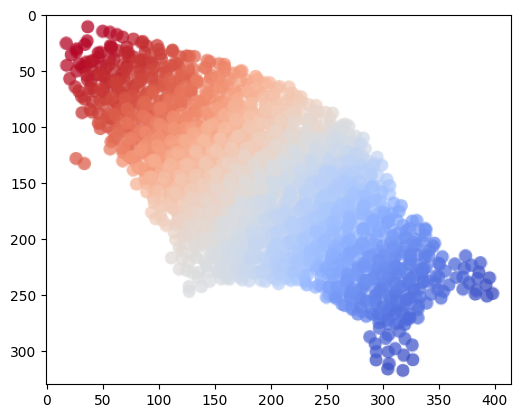

In [32]:
plt.imshow(figures_eigenmodes[0])

# Part 2: Measuring whole-brain connectivity

In [84]:
from calimba.visualization import *

def values_to_colormap(values, cmap='viridis'):
    norm = plt.Normalize(vmin=np.min(values), vmax=np.max(values))
    colormap = plt.get_cmap(cmap)
    colors = [colormap(norm(value))[:3] for value in values]
    return colors

In [85]:
atlas_path = '/home/anleg84/Documents/Atlas/Mapzebrain/'
atlas = Mapzebrain(atlas_path)

neurons = Neurons(atlas) # Class that loads all neuron morphologies

somas = atlas.trim_centroids(neurons.somas) # Make sure the coordinates are within the atlas XYZ field of view
somas = np.round(somas).astype('int')

### Plotting neurons brain-wide

In [86]:
n_plotted = 4327
n_neurons = neurons.somas.shape[0]
random_subset = np.random.choice(n_neurons, n_plotted, replace=False)

#colors = generate_n_colors(10) * 1000
#colors = values_to_colormap(np.random.uniform(0, 1, n_plotted), cmap='rainbow')
colors = values_to_colormap(somas[random_subset, 1], cmap='rainbow')

In [87]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
ax.imshow(atlas.XYprojection, cmap='gray', alpha=0)
ax.axis('off')
for j, i in enumerate(random_subset):
    neurons.plot_top(ax, i, color=colors[j], alpha=0.1, soma_size=5, terminals=False)
ax.set_xlim([70, 500])
ax.set_ylim([850, 50])

plt.tight_layout(pad=0)
plt.savefig('../Figures/figure7_projectome.png')
plt.show()


KeyboardInterrupt



Error in callback <function flush_figures at 0x735821d389d0> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(atlas.YZprojection, cmap='gray', alpha=0)
ax.axis('off')
for j, i in enumerate(random_subset):
    neurons.plot_side(ax, i, color=colors[j], alpha=0.1, soma_size=5)
#ax.set_xlim([, 500])
ax.set_ylim([850, 50])
plt.tight_layout(pad=0)
plt.show()

### Inter-regional connectivity

In [ ]:
from scipy.stats import kstest

def compute_ks_distance(centroids, gamma, n_samples=100):
    connected_distances_random = generate_random_samples(centroids, gamma, n_samples)
    return kstest(connected_distances, connected_distances_random)[0]

def generate_random_samples(centroids, gamma, n_samples):
    connected_distances_random = []
    for _ in range(n_samples):
        W_random = (generate_connectivity_matrix_EDR(centroids, gamma=gamma) > 0).astype('float')
        connected_distances_random.append(distances[triangle][W_random[triangle] > 0])
    connected_distances_random = np.concatenate(connected_distances_random)
    return connected_distances_random

In [91]:
neurons.compute_connectivity()

Mapping terminals...


100%|███████████████████████████████████████████| 65/65 [00:31<00:00,  2.08it/s]


Mapping somas...


100%|███████████████████████████████████████████| 65/65 [00:28<00:00,  2.32it/s]


Compiling connections...
Done!


In [92]:
W = neurons.W_undirected

In [93]:
plt.imshow(W, cmap='binary')

### EDR distribution fit

In [94]:
distances = compute_distances(atlas.region_centroids, atlas.region_centroids)
distances = (1 / 3) * (distances[:65, :65] + distances[:65, 65:] + distances[65:, 65:])
triangle = np.triu_indices(W.shape[0], 1)
connected_distances = distances[triangle][W[triangle] != 0]

In [95]:
d, prob = measure_connection_probabilities(W, distances, d_min=0, d_max=800, n_bins=30)

In [96]:
plt.plot(d, prob)

In [243]:
steps = 30
    
# Multi-step optimization
gamma_0 = 0.01
delta = 0.05
for _ in tqdm(range(steps)):
    gamma_values = np.linspace(np.clip(gamma_0 - delta, 0, gamma_0), gamma_0 + delta, 50)
    ks_distances = []
    for gamma in gamma_values:
        ks_distances.append(compute_ks_distance(atlas.region_centroids[:65], gamma, n_samples=10))
    gamma_0 = gamma_values[np.argmin(gaussian_filter1d(ks_distances, 2))]
    delta *= 0.66
    
gamma_opt = gamma_0   

100%|██████████████████████████████████████████| 50/50 [00:00<00:00, 226.05it/s]


In [250]:
print(gamma_opt)

0.003965255218569357


### Inspecting distributions

In [101]:
# Randomly sampled connection distances from EDR rule
gamma = gamma_opt

connected_distances_random = []
for _ in range(2000):
    W_random = (generate_connectivity_matrix_EDR(atlas.region_centroids[:65], gamma=gamma) > 0).astype('float')
    connected_distances_random.append(distances[triangle][W_random[triangle] > 0])
connected_distances_random = np.concatenate(connected_distances_random)

In [105]:
kstest(connected_distances, connected_distances_random)

KstestResult(statistic=0.021402075864127568, pvalue=0.804010535496928)

In [106]:
bins = np.linspace(0, 800, 50, endpoint=True)

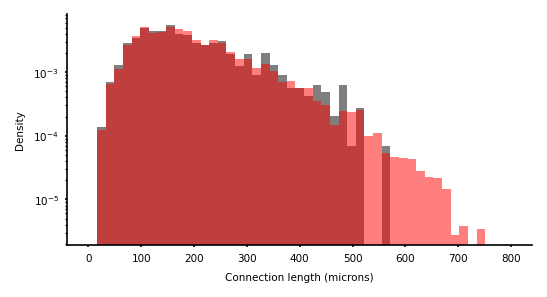

In [111]:
fig, ax = plt.subplots(figsize=(4, 2), dpi=150)
plt.hist(connected_distances, bins=bins, density=True, color='black', alpha=0.5)
plt.hist(connected_distances_random, bins=bins, density=True, color='red', alpha=0.5)
#ax.axvline(predicted_radius, color='red')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Connection length (microns)')
ax.set_ylabel('Density')
plt.yscale('log')
plt.show()

In [112]:
x = np.linspace(0, 800, 1000)
y = exponential_function(x, 0.0040, 1, 0)

In [113]:
x[np.where(y < 0.1)[0][0]]

575.7757757757759

### Comparing functional exponential decays at different scales

In [129]:
def compute_correlation_curve(C, D, d_max=0.5, n_bins=21):
    distances = D
    bins = np.linspace(0, d_max, n_bins, endpoint=True)
    d_values = bins[:-1] + ((bins[1] - bins[0]) / 2)
    avg_corr_per_dist = []
    std_corr_per_dist = []
    for i in range(len(bins) - 1):
        corrs_in_bin = C[(distances > bins[i]) & (distances <= bins[i + 1])]
        avg_corr_per_dist.append(np.mean(corrs_in_bin))
        std_corr_per_dist.append(np.std(corrs_in_bin))
    return d_values, np.array(avg_corr_per_dist), np.array(std_corr_per_dist)

In [130]:
%matplotlib inline

In [131]:
d = compute_distances(nodes, nodes)
R = FC.shape[0]
d = (1 / 3) * (d[:R, :R] + d[R:, R:] + d[:R, R:])

In [132]:
D1, C1 = d, FC
D2, C2 = np.load('../Results/figure6_scatter_distance.npy')

In [133]:
d1, curve1, std1 = compute_correlation_curve(C1, D1, d_max=750, n_bins=15)
d2, curve2, std2 = compute_correlation_curve(C2, D2, d_max=270, n_bins=15)

Text(0, 0.5, 'FC')

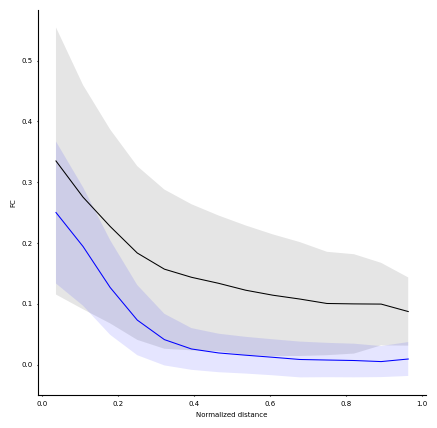

In [134]:
fig, ax = plt.subplots(figsize=(5, 5))
x = np.linspace(0, 1, 100, endpoint=True)
#ax.plot(x, exponential_function(x, 0.0040 * 750, 1, 0) * 0.35, linewidth=0.75, color='black')
#ax.plot(x, exponential_function(x, 0.0331 * 270, 1, 0) * 0.25, linewidth=0.75, color='blue')

plt.plot(d1 / 750, (curve1), color='black', linewidth=0.75)
plt.plot(d2 / 270, (curve2), color='blue', linewidth=0.75)
ax.fill_between(d1 / 750, curve1 - std1, curve1 + std1, color='black', edgecolor='None', alpha=0.1)
ax.fill_between(d2 / 270, curve2 - std2, curve2 + std2, color='blue', edgecolor='None', alpha=0.1)
ax.spines[['top', 'right']].set_visible(False)
plt.xlabel('Normalized distance')
plt.ylabel('FC')

# Rendering figure

In [135]:
density = compute_scatter_density(d_values, FC_values)

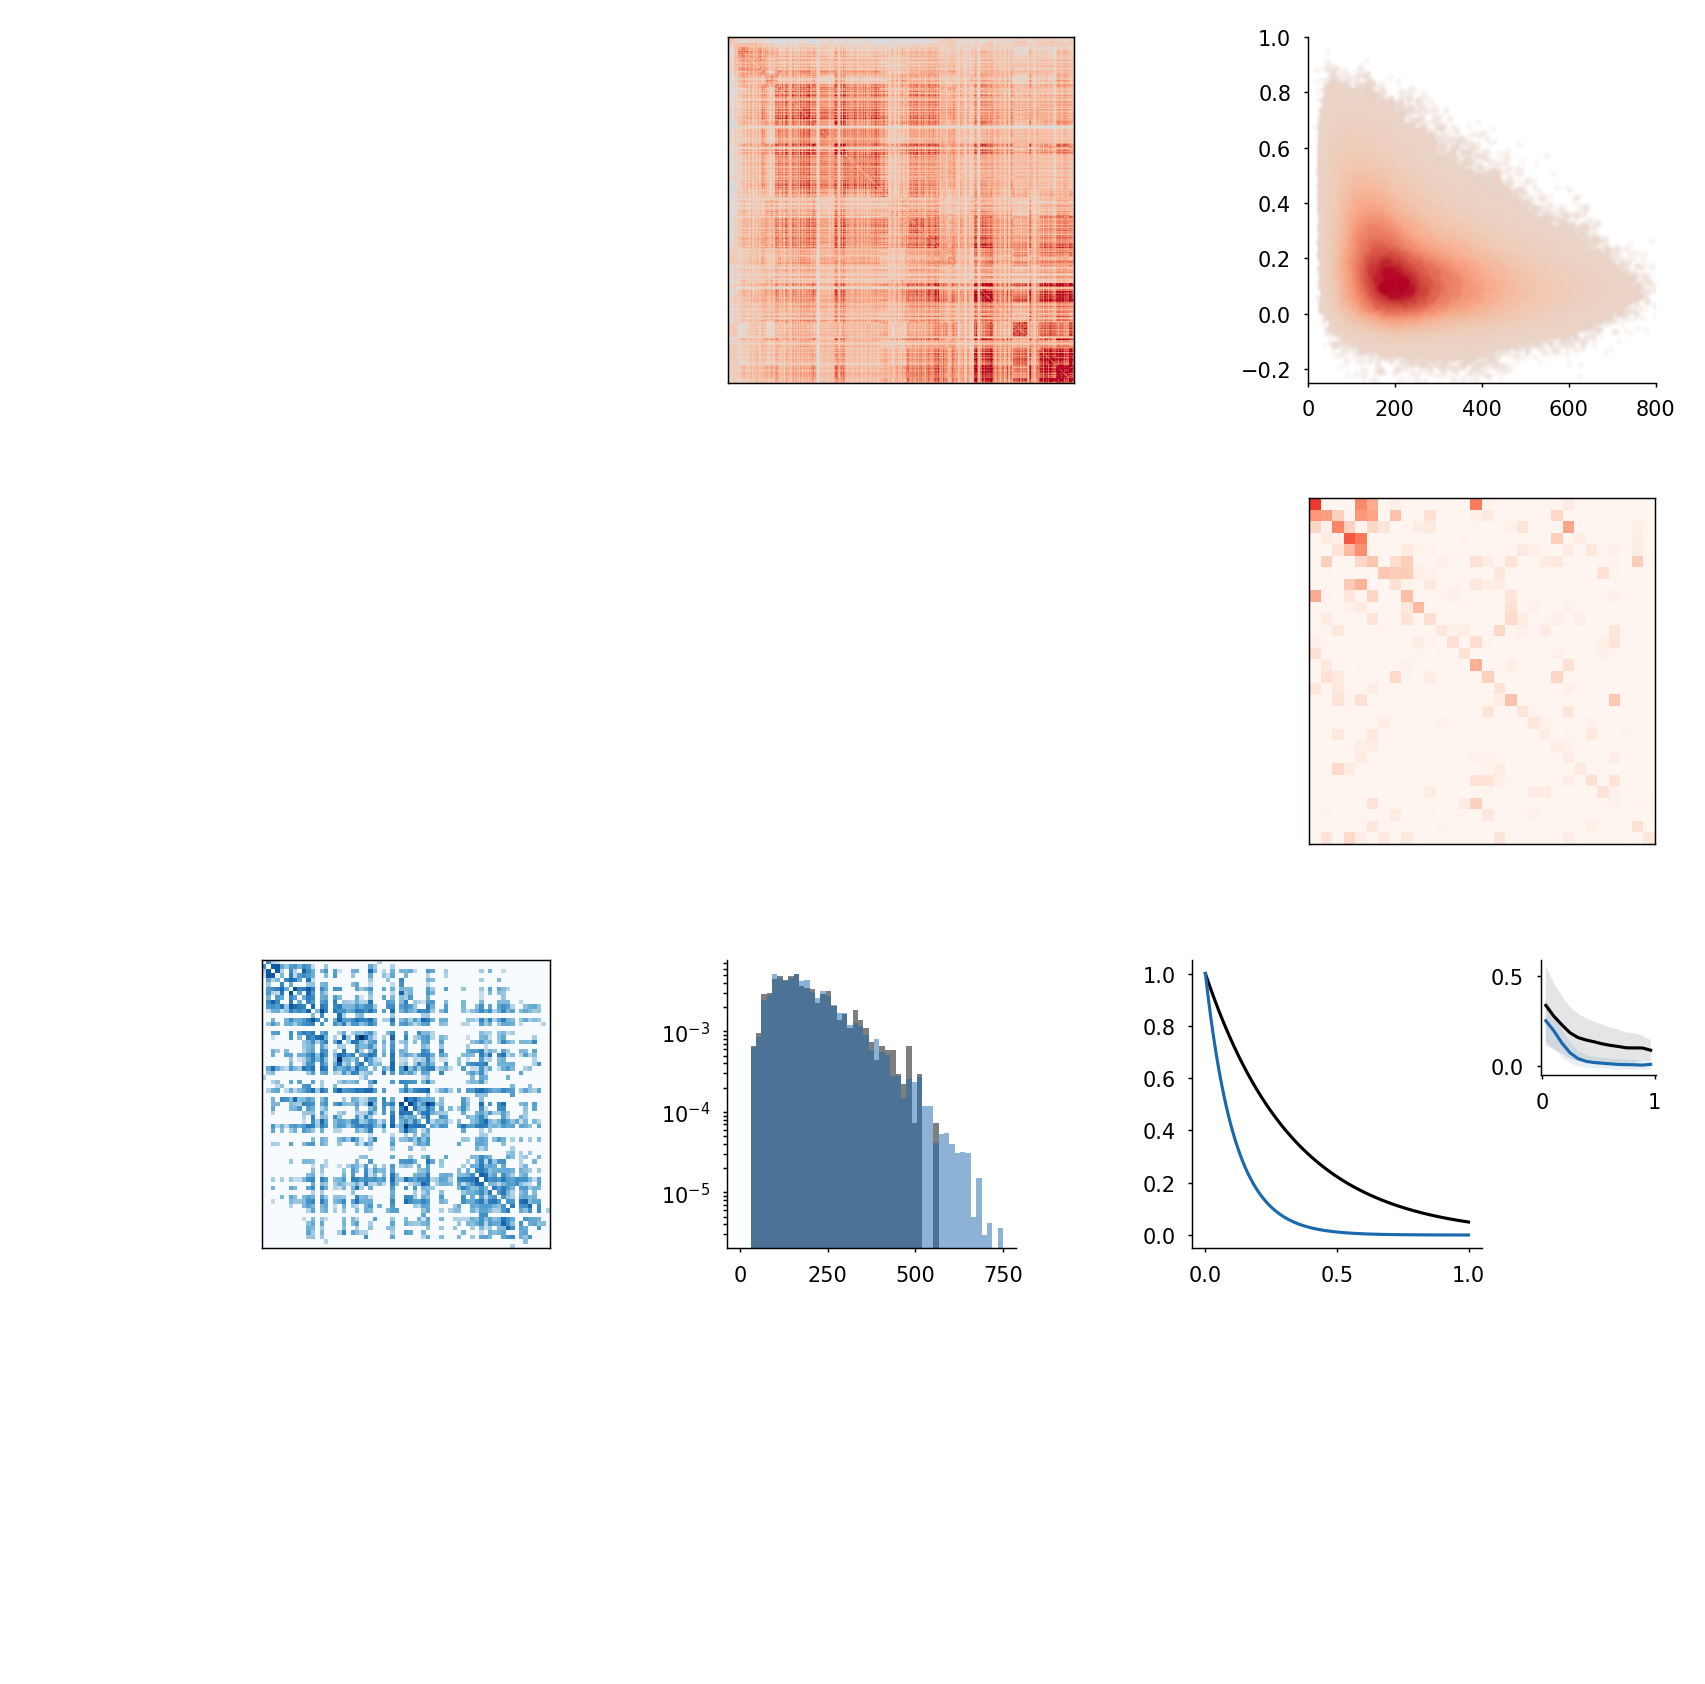

In [139]:
fig = PaperFigure(figsize=(7, 7), dpi=300)

fig.set_tick_length(1)
fig.set_font_size(5)
fig.add_background()

# Adding axes ----------------------------------------------------------------------------

w = 1.5
fig.add_axes('correlations', (3, 0), w, w)
fig.add_axes('scatter', (5.5, 0), w, w)

N_modes = 7
w = 5 / N_modes
for i in range(N_modes):
    fig.add_axes(f'eigenmode{i}', (i * w, 2), w, w)
    fig.add_axes(f'gradient{i}', (i * w, 2 + w), w, w)

fig.add_axes('mapping', (5.5, 2), 1.5, 1.5)
#fig.add_axes('neurons_top', (0, 4), 1.5 * 0.6, 1.5)
#fig.add_axes('neurons_side', (1.5 * 0.6, 4), 1.5 * 0.4, 1.5)
fig.add_axes('connectivity', (1, 4), 1.25, 1.25)
fig.add_axes('distributions', (3, 4), 1.25, 1.25)
fig.add_axes('exponentials', (5, 4), 1.25, 1.25)
fig.add_axes('exponentials_functional', (6.5, 4), 0.5, 0.5)

fig.set_line_thickness(0.35)

# Filling content ------------------------------------------------------------------------

ax = fig.axes['correlations']
ax.imshow(FC, cmap='coolwarm', vmin=-0.5, vmax=0.5)
ax.set_xticks([])
ax.set_yticks([])

ax = fig.axes['scatter']
#ax.scatter(d_values, FC_values, s=0.25, edgecolor=None, alpha=0.1, color='black')
o = np.argsort(density)
v = np.max(density)
ax.scatter(d_values[o], FC_values[o], edgecolor=None, c=density[o], cmap='coolwarm', s=1, alpha=0.1, vmin=-1.25 * v, vmax=v, rasterized=True)
#ax.set_xticks([0, 275])
ax.set_xlim([0, 800])
ax.set_ylim([-0.25, 1.0])
#ax.set_yticks([0, 0.6])
ax.spines[['top', 'right']].set_visible(False)

for i in range(N_modes):
    ax = fig.axes[f'eigenmode{i}']
    #ax.imshow(figures_eigenmodes[i], aspect='auto')
    ax.axis('off')

for i in range(N_modes):
    ax = fig.axes[f'gradient{i}']
    #ax.imshow(figures_gradients[mapping[i]], aspect='auto')
    ax.axis('off')

ax = fig.axes['mapping']
ax.imshow(np.abs(mode_similarity), cmap='Reds', vmin=0.1, vmax=0.75)
ax.set_xticks([])
ax.set_yticks([])

ax = fig.axes['connectivity']
order = np.argsort(somas[:, 1])
#ax.imshow((W != 0)[order, :][:, order], cmap='binary', vmin=0, vmax=0.1)
ax.imshow(W, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks([])
ax.set_yticks([])

blue = plt.get_cmap('Blues')(200)
ax = fig.axes['distributions']
bins = np.linspace(0, 750, 50, endpoint=True)
ax.hist(connected_distances, bins=bins, density=True, color='black', alpha=0.5)
ax.hist(connected_distances_random, bins=bins, density=True, color=blue, alpha=0.5)
ax.set_yscale('log')
ax.spines[['top', 'right']].set_visible(False)

ax = fig.axes['exponentials']
x = np.linspace(0, 1, 100, endpoint=True)
ax.plot(x, exponential_function(x, 0.0040 * 750, 1, 0), linewidth=0.75, color='black')
ax.plot(x, exponential_function(x, 0.0331 * 270, 1, 0), linewidth=0.75, color=blue)
ax.spines[['top', 'right']].set_visible(False)

ax = fig.axes['exponentials_functional']
ax.plot(d1 / 750, (curve1), color='black', linewidth=0.75)
ax.plot(d2 / 270, (curve2), color=blue, linewidth=0.75)
ax.fill_between(d1 / 750, curve1 - std1, curve1 + std1, color='black', edgecolor='None', alpha=0.1)
ax.fill_between(d2 / 270, curve2 - std2, curve2 + std2, color=blue, edgecolor='None', alpha=0.1)
ax.spines[['top', 'right']].set_visible(False)

fig.show()

In [140]:
fig.save('../Figures/figure7_incomplete.svg')

#### Manually annotated values

Ordering of gradients

In [ ]:
print(mapping)